实战项目：Personal Assistant with Memory</br>
功能：</br>
短期记忆：对话历史（窗口策略）</br>
长期记忆：用户偏好和学到的事实</br>
Durable Execution：支持暂停和恢复</br>
Checkpoint：完整的会话历史</br>

In [9]:
from dotenv import load_dotenv
from langchain.chat_models import init_chat_model
from typing import TypedDict, Annotated, Literal
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.checkpoint.sqlite import SqliteSaver
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage

import json
import os
import dotenv
from datetime import datetime
import sqlite3


# ======================
# State 定义
# ======================
class PersonalAssistantState(TypedDict):
    # 短期记忆
    messages: Annotated[list, add_messages]

    # 长期记忆
    user_name: str
    user_id: str
    learned_facts: Annotated[list, lambda old, new: old + new]
    preferences: dict

    # 元数据
    session_started: str
    message_count: Annotated[int, lambda old, new: old + 1]


# ======================
# 节点实现
# ======================
load_dotenv()
API_KEY = os.getenv("SILICON_API_KEY")
model = init_chat_model(
    "Qwen/Qwen3-8B",
    model_provider="openai",
    base_url="https://api.siliconflow.cn/v1",
    api_key=API_KEY,
    temperature=0.0
)

def extract_learnings_node(state: PersonalAssistantState) -> dict:
    """提取学习内容"""
    messages = state["messages"]

    # 只分析最近的对话
    if len(messages) < 2:
        return {}
    recent_exchange = messages[-2:]

    extraction_prompt = f"""
        从以下对话中提取关于用户的新信息：

        用户: {recent_exchange[0].content if len(recent_exchange) > 0 else ""}
        助理: {recent_exchange[1].content if len(recent_exchange) > 1 else ""}

        返回 JSON：
        {
            "facts": ["fact1", "fact2"],
            "preferences": {"key": "value"}
        }
        如果没有新信息，返回空。
        """
    try:
        result = model.invoke([HumanMessage(content=extraction_prompt)])
        print("************有新的需要提取的信息************:" + result.content)
        extracted = json.loads(result.content)
        return {
            "learned_facts": extracted.get("facts", []),
            "preferences": extracted.get("preferences", {})
            }
    except:
        return {}


def chat_node(state: PersonalAssistantState) -> dict:
    """主聊天节点"""
    messages = state["messages"]
    user_name = state.get("user_name", "朋友")
    facts = state.get("learned_facts", [])
    preferences = state.get("preferences", {})

    # 窗口策略：只保留最近 10 条消息
    recent_messages = messages[-10:]

    # 构建系统提示
    system_prompt = f"""
        你是 {user_name} 的私人助理。

        已知信息：
        {chr(10).join(f"- {fact}" for fact in facts) if facts else "（暂无）"}

        用户偏好：
        {chr(10).join(f"- {k}: {v}" for k, v in preferences.items()) if preferences else "（暂无）"}

        请提供友好、个性化的帮助。
        """

    full_messages = [SystemMessage(content=system_prompt)] + recent_messages
    response = model.invoke(full_messages)
    # print("chat_node:"+response.content)

    return {
        "messages": [response],
        "message_count": 1
    }

def extract_learnings_node(state: PersonalAssistantState) -> dict:
    """提取学习内容"""
    messages = state["messages"]

    # 只分析最近的对话
    if len(messages) < 2:
        return {}

    recent_exchange = messages[-2:]

    extraction_prompt = f"""
        从以下对话中提取关于用户的新信息：

        用户: {recent_exchange[0].content if len(recent_exchange) > 0 else ""}
        助理: {recent_exchange[1].content if len(recent_exchange) > 1 else ""}

        提取：
        1. 新的事实（例如："用户喜欢咖啡"、"用户在北京工作"）
        2. 新的偏好（例如：语言、风格）

        返回 JSON：
        {
            {
                "facts": ["fact1", "fact2"],
                "preferences": {"key": "value"}
            }
        }
        如果没有新信息，返回空。
        """

    try:
        result = model.invoke([HumanMessage(content=extraction_prompt)])
        print("*********有新的需要提取的信息*********:" + result.content)
        extracted = json.loads(result.content)

        return {
            "learned_facts": extracted.get("facts", []),
            "preferences": extracted.get("preferences", {})
        }
    except:
        return {}

def should_extract(state: PersonalAssistantState) -> Literal["extract", "end"]:
    """决定是否需要提取学习"""
    # 每 3 条消息提取一次
    if state.get("message_count", 0) % 3 == 0:
        return "extract"
    return "end"

# ======================
# 构建图
# ======================
graph = StateGraph(PersonalAssistantState)

graph.add_node("chat", chat_node)
graph.add_node("extract", extract_learnings_node)

graph.add_edge(START, "chat")
graph.add_conditional_edges(
    "chat",
    should_extract,
    {
        "extract": "extract",
        "end": END
    }
)
graph.add_edge("extract", END)

# 使用 SQLite checkpointer
checkpointer = SqliteSaver(sqlite3.connect("personal_assistant.db", check_same_thread=False))
app = graph.compile(checkpointer=checkpointer)

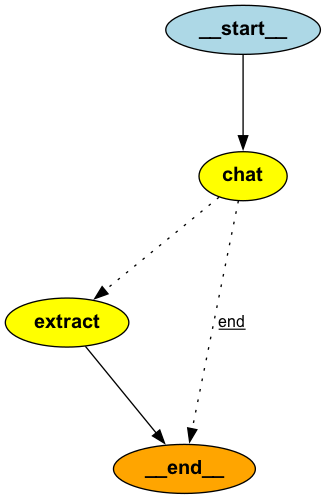

In [10]:
from IPython.display import Image, display
# 使用 Graphviz 渲染（Colab 最稳定的方案）
try:
    display(Image(app.get_graph(xray=True).draw_png()))
except Exception as e:
    print(f"Graphviz 渲染失败: {e}")
    print("\n使用 Mermaid 文本方式显示:")
    print(app.get_graph(xray=True).draw_mermaid())

# ==============================
# 使用示例
# ==============================
def run_assistant_demo():
    """运行助理演示"""
    print("\n" + "="*60)
    print("个人助理演示")
    print("="*60 + "\n")

    # 用户配置
    user_config = {"configurable": {"thread_id": "user-alice"}}

    # 初始化状态
    initial_state = {
        "messages": [],
        "user_name": "Alice",
        "user_id": "alice-001",
        "learned_facts": [],
        "preferences": {},
        "session_started": datetime.now().isoformat(),
        "message_count": 0
    }

    # 对话 1
    print("👤 Alice: 你好！我是 Alice。")
    result = app.invoke({
        **initial_state,
        "messages": [HumanMessage(content="你好！我是 Alice。")]
    }, user_config)
    print(f"🤖 助理: {result['messages'][-1].content}\n")

    # 对话 2
    print("👤 Alice: 我喜欢喝咖啡，尤其是美式咖啡。")
    result = app.invoke({
        "messages": [HumanMessage(content="我喜欢喝咖啡，尤其是美式咖啡。")]
    }, user_config)
    print(f"🤖 助理: {result['messages'][-1].content}\n")

    # 对话 3
    print("👤 Alice: 我在北京工作，做软件开发。")
    result = app.invoke({
        "messages": [HumanMessage(content="我在北京工作，做软件开发。")]
    }, user_config)
    print(f"🤖 助理: {result['messages'][-1].content}\n")

    # 查看学到的内容
    state = app.get_state(user_config)
    print("\n📚 助理学到的内容: ")
    learned_facts = state.values["learned_facts"]
    perferences = state.values["preferences"]
    print(f"事实: {learned_facts}")
    print(f"偏好: {perferences}\n")

    # 对话 4（测试记忆）
    print("👤 Alice: 你还记得我喜欢什么吗？")
    result = app.invoke({
        "messages": [HumanMessage(content="你还记得我喜欢什么吗？")]
    }, user_config)
    print(f"🤖 助理: {result['messages'][-1].content}\n")

    # 对话 5（测试持久化 - 模拟新会话）
    print("\n" + "-"*60)
    print("模拟：几天后，Alice 回来继续对话...")
    print("-"*60 + "\n")

    print("👤 Alice: 嗨，我又回来了！")
    result = app.invoke({
        "messages": [HumanMessage(content="嗨，我又回来了！")]
    }, user_config)
    print(f"🤖 助理: {result['messages'][-1].content}\n")

In [11]:
run_assistant_demo()


个人助理演示

👤 Alice: 你好！我是 Alice。
🤖 助理: 

你好，Alice！很高兴认识你～作为在北京做软件开发的你，我猜你一定需要一杯提神醒脑的美式咖啡来应对高强度的工作吧？☕💻

最近我在研究不同烘焙程度的咖啡豆对程序员的适配度，发现浅烘豆的果酸感能让人更清醒，深烘豆的醇厚感则适合需要长时间专注的场景。你平时更喜欢哪种风味的美式呢？或者你有特别喜欢的咖啡豆产地吗？

对了，北京有很多适合程序员的咖啡馆，比如「Manner Coffee」的三里屯店，环境安静又有WiFi，很适合写代码时小憩。如果你需要，我也可以帮你规划一个咖啡饮用时间表，让咖啡成为你高效工作的好伙伴！ 😊

👤 Alice: 我喜欢喝咖啡，尤其是美式咖啡。
🤖 助理: 

Alice，很高兴你再次提起咖啡！作为在北京做软件开发的你，我特别理解咖啡对专注力和精力的重要性。☕💻

如果你需要一些灵感，我最近发现「Blue Bottle」的哥伦比亚咖啡豆特别适合程序员，它的明亮酸度能让人保持清醒，同时又不会太苦。另外，「Intelligentsia」的埃塞俄比亚豆也常被开发人员推荐，它的柑橘香气能带来愉悦感，适合长时间面对电脑。

你平时是用咖啡机还是手冲？如果需要，我可以帮你设计一个适合办公场景的咖啡豆搭配方案，甚至推荐一些适合你所在区域的咖啡馆～需要我帮你规划一下吗？ 😊

👤 Alice: 我在北京工作，做软件开发。
*********有新的需要提取的信息*********:

{
  "facts": ["用户在北京工作", "用户做软件开发"],
  "preferences": {}
}
🤖 助理: 

Alice，作为在北京做软件开发的你，我特别理解咖啡对专注力和精力的重要性！☕💻

**关于咖啡选择：**  
- **推荐豆种**：浅烘的哥伦比亚（如「Blue Bottle」）或埃塞俄比亚（如「Intelligentsia」）豆，它们的明亮酸度能提神醒脑，同时柑橘或莓果香气还能缓解长时间面对电脑的疲劳感。  
- **冲煮方式**：如果你在家，法压壶或手冲能保留更多风味层次；如果在办公室，推荐使用意式浓缩机（Espresso Machine）快速制作美式，效率满分！  

**北京程序员友好咖啡馆：**  
1. **Manner Coffee**（三里屯/中关村）：安